In [1]:
from google.colab import drive
drive.mount('/content/drive')

root_dir = '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE'

Mounted at /content/drive


In [2]:
!pip install -U ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:0000:01


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2

import os
import shutil
import random
import xml.etree.ElementTree as ET
import yaml
from pathlib import Path
from collections import Counter

from ultralytics import YOLO
from sklearn.model_selection import KFold

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Notebook Roadmap

- Mount Drive and set dataset paths
- Read Pascal VOC XML annotations
- Build and inspect the annotation dataframe
- Resize images and convert boxes to YOLO format
- Split data and create K-fold folds
- Train YOLOv8 on each fold
- Load the best weights for testing
- Run inference and visualize predictions

In [4]:
dataset_dir = os.path.join(root_dir, 'PCB_DATASET')

for root, dirs, files in os.walk(dataset_dir):
   for name in dirs:
      print(os.path.join(root, name))

/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/Annotations
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/PCB_USED
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/images
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/rotation
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/train
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/val
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/test
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/resized_images
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/images_resized
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/Annotations/Missing_hole
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/Annotations/Open_circuit
/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/Annotations/Mouse_bite
/conte

In [5]:
def count_files_in_folder(folder_path):
    # Get list of all files in the folder
    files = os.listdir(folder_path)

    # Count the number of files
    num_files = len(files)

    return num_files

In [6]:
subfolders = ['Missing_hole', 'Mouse_bite', 'Open_circuit', 'Short', 'Spur', 'Spurious_copper']

images_dir = os.path.join(dataset_dir, 'images')
annot_dir = os.path.join(dataset_dir, 'Annotations')

for subfolder in subfolders:
    images_path = os.path.join(images_dir, subfolder)
    annot_path = os.path.join(annot_dir, subfolder)

    print(f'{subfolder:<15} \t\
            {count_files_in_folder(images_path)} images \t\
            {count_files_in_folder(annot_path)} annotations')

Missing_hole    	            115 images 	            115 annotations
Mouse_bite      	            115 images 	            115 annotations
Open_circuit    	            116 images 	            116 annotations
Short           	            116 images 	            116 annotations
Spur            	            115 images 	            115 annotations
Spurious_copper 	            116 images 	            116 annotations


# 1. Build annotation dataframe

In [7]:
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()
    data = []

    filename = root.find('filename').text
    width = int(root.find('size/width').text)
    height = int(root.find('size/height').text)

    for obj in root.findall('object'):
        name = obj.find('name').text
        xmin = int(obj.find('bndbox/xmin').text)
        ymin = int(obj.find('bndbox/ymin').text)
        xmax = int(obj.find('bndbox/xmax').text)
        ymax = int(obj.find('bndbox/ymax').text)

        data.append({
            'filename': filename,
            'width': width,
            'height': height,
            'class': name,
            'xmin': xmin,
            'ymin': ymin,
            'xmax': xmax,
            'ymax': ymax
        })

    return data

In [8]:
dataset_dir = "/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET"
annot_dir = os.path.join(dataset_dir, "Annotations")
images_dir = os.path.join(dataset_dir, "images")

In [9]:
# Load cached annotations if they exist; otherwise parse the XML files once and cache them.
annotations_cache = os.path.join(dataset_dir, 'annotations_cache.csv')

if os.path.exists(annotations_cache):
    annot_df = pd.read_csv(annotations_cache)
else:
    all_data = []

    # Recursively traverse subdirectories
    for root, dirs, files in os.walk(annot_dir):
        for name in files:
            if name.endswith('.xml'):
                xml_path = os.path.join(root, name)
                all_data.extend(parse_xml(xml_path))

    # Create DataFrame from the parsed data
    annot_df = pd.DataFrame(all_data)
    annot_df.to_csv(annotations_cache, index=False)


In [10]:
# Create DataFrame from the parsed data
annot_df = pd.DataFrame(all_data)
annot_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax
0,01_missing_hole_05.jpg,3034,1586,missing_hole,804,298,860,365
1,01_missing_hole_05.jpg,3034,1586,missing_hole,279,294,353,374
2,01_missing_hole_05.jpg,3034,1586,missing_hole,1068,1051,1110,1107
3,01_missing_hole_05.jpg,3034,1586,missing_hole,1613,392,1677,460
4,01_missing_hole_02.jpg,3034,1586,missing_hole,2584,232,2650,298


# 2. Visualize annotations

In [11]:
def get_subfolder(image_name):
    if 'missing' in image_name.split('_'):
        return 'Missing_hole'
    if 'mouse' in image_name.split('_'):
        return'Mouse_bite'
    if 'open' in image_name.split('_'):
        return 'Open_circuit'
    if 'short' in image_name.split('_'):
        return 'Short'
    if 'spur' in image_name.split('_'):
        return 'Spur'
    if 'spurious' in image_name.split('_'):
        return 'Spurious_copper'

In [12]:
def visualize_annotations(image_name, images_dir, annot_df, is_subfolder=False):
    # Construct path for image
    if is_subfolder:
        image_path = os.path.join(images_dir, get_subfolder(image_name), image_name)
    else:
        image_path = os.path.join(images_dir, image_name)


    # Read image
    image = cv2.imread(image_path)

    # Filter annotations for the current image
    annotations = annot_df[annot_df['filename'] == image_name]

    # Draw bounding boxes on the image
    for _, annot in annotations.iterrows():
        xmin, ymin, xmax, ymax = annot['xmin'], annot['ymin'], annot['xmax'], annot['ymax']
        class_label = annot['class']

        # Check if confidence column exists
        confidence = annot.get('confidence')
        if confidence is not None:
            class_label += f" ({confidence:.2f})"

        color = (255, 255, 255)
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), color, 3)

        # Add background to the text
        text_size = cv2.getTextSize(class_label, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 2)[0]
        cv2.rectangle(image, (xmin, ymin - text_size[1] - 5),
                             (xmin + text_size[0], ymin - 1), color, -1)

        # Add text
        cv2.putText(image, class_label, (xmin, ymin - 5), cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 2)

    # Convert BGR image to RGB (Matplotlib expects RGB)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Plot the image with annotations
    plt.figure(figsize=(18, 10))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.title('Annotations')
    plt.text(10, image_rgb.shape[0] + 100, f'Image: {image_name}',
             color='black', fontsize=11, ha='left')
    plt.show()

    return image


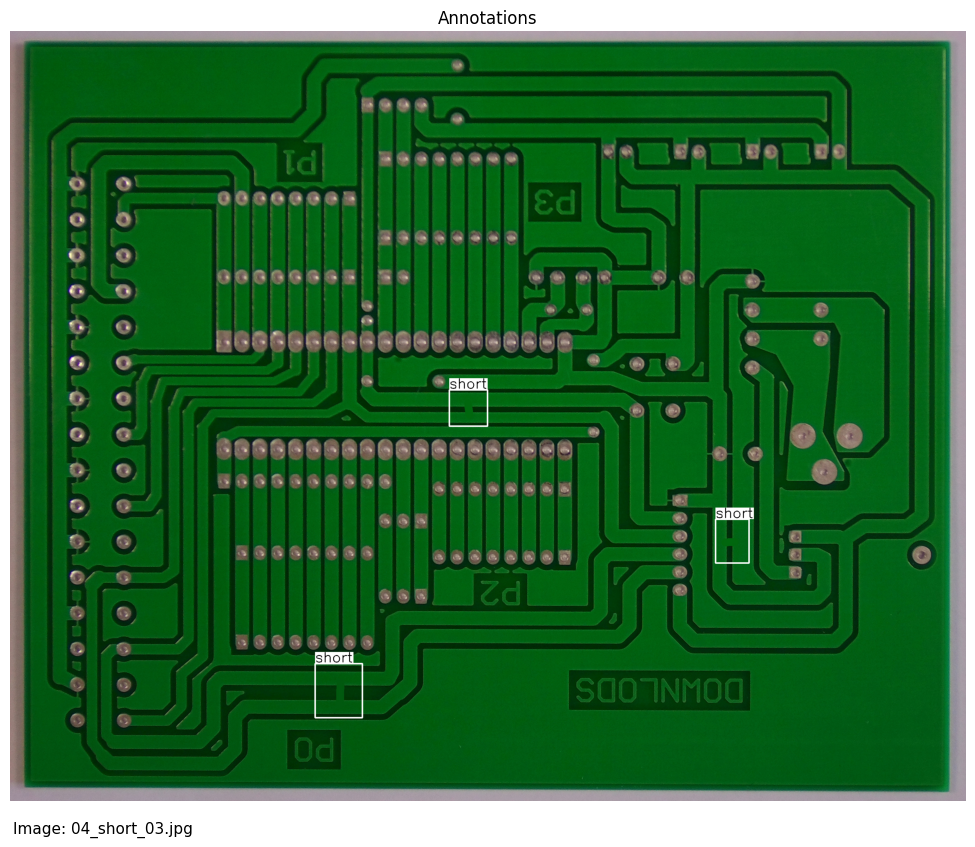

In [13]:
image_name = '04_short_03.jpg'
visualize_annotations(image_name, images_dir, annot_df, is_subfolder=True);

# 3. Preprocess images and boxes

In [15]:
output_dir = os.path.join(dataset_dir, 'output')
prepared_images_dir = os.path.join(output_dir, 'images', 'train')
prepared_labels_dir = os.path.join(output_dir, 'labels', 'train')
rebuild_dataset = not (os.path.isdir(prepared_images_dir) and os.path.isdir(prepared_labels_dir))

def resize_images(input_dir, output_dir, target_size=(640, 640)):
    # Create the output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Traverse through the subfolders in the input folder
    for root, _, files in os.walk(input_dir):
        for file in files:
            # Check if the file is an image
            if file.lower().endswith(('.jpg')):
                # Read the image
                image_path = os.path.join(root, file)
                image = cv2.imread(image_path)

                # Resize the image
                resized_image = cv2.resize(image, target_size)

                # Save the resized image to the output folder
                output_path = os.path.join(output_dir, file)
                cv2.imwrite(output_path, resized_image)

resized_img_dir = os.path.join(dataset_dir, 'images_resized')

if rebuild_dataset:
    resize_images(images_dir, resized_img_dir)
else:
    print(f'Using existing prepared dataset at {output_dir}')


Using existing prepared dataset at /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output


In [16]:
if rebuild_dataset:
    def resize_annotations(annot_df, target_size=(640, 640)):
        all_data = []

        # Iterate through the annotation DataFrame
        for index, row in annot_df.iterrows():

            # Resize the bounding box coordinates
            width_ratio = target_size[0] / row['width']
            height_ratio = target_size[1] / row['height']

            resized_xmin = int(row['xmin'] * width_ratio)
            resized_ymin = int(row['ymin'] * height_ratio)
            resized_xmax = int(row['xmax'] * width_ratio)
            resized_ymax = int(row['ymax'] * height_ratio)

            # Update the all data list with resized annotations
            all_data.append({
                'filename': row['filename'],
                'width': target_size[0],
                'height': target_size[1],
                'class': row['class'],
                'xmin': resized_xmin,
                'ymin': resized_ymin,
                'xmax': resized_xmax,
                'ymax': resized_ymax
            })

        annot_df_resized = pd.DataFrame(all_data)
        return annot_df_resized

    annot_df_resized = resize_annotations(annot_df)
else:
    annot_df_resized = annot_df.copy()

annot_df_resized.head()


,filename,width,height,class,xmin,ymin,xmax,ymax
0,01_missing_hole_05.jpg,3034,1586,missing_hole,804,298,860,365
1,01_missing_hole_05.jpg,3034,1586,missing_hole,279,294,353,374
2,01_missing_hole_05.jpg,3034,1586,missing_hole,1068,1051,1110,1107
3,01_missing_hole_05.jpg,3034,1586,missing_hole,1613,392,1677,460
4,01_missing_hole_02.jpg,3034,1586,missing_hole,2584,232,2650,298


# 4. Prepare YOLO splits

In [17]:
# Create the output directory
output_dir = os.path.join(dataset_dir, 'output')
os.makedirs(output_dir, exist_ok=True)

In [18]:
# Convert annotation DataFrame into YOLO labels
# YOLO format: <class_index> <x_center> <y_center> <width> <height>
def convert_to_yolo_labels(annotation_df, classes, target_size=(640, 640)):
    yolo_labels = []

    for _, annot in annotation_df.iterrows():
        filename = annot['filename']
        width, height = annot['width'], annot['height']
        class_name = annot['class']
        xmin, ymin, xmax, ymax = annot['xmin'], annot['ymin'], annot['xmax'], annot['ymax']

        # Convert bounding box coordinates to YOLO format
        x_center = (xmin + xmax) / (2 * width)
        y_center = (ymin + ymax) / (2 * height)
        bbox_width = (xmax - xmin) / width
        bbox_height = (ymax - ymin) / height

        class_index = classes.index(class_name)

        # Append to YOLO labels list
        yolo_labels.append((filename, class_index, x_center, y_center, bbox_width, bbox_height))

    return yolo_labels


classes = ['missing_hole', 'mouse_bite', 'open_circuit',
           'short', 'spur', 'spurious_copper']
yolo_labels = convert_to_yolo_labels(annot_df_resized, classes)


In [19]:
def split_images_and_labels(images_dir, labels, output_dir, train_split=0.95, val_split=0.05):
    # os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images/train'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images/val'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'images/test'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels/train'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels/val'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'labels/test'), exist_ok=True)

    # Group labels by image filename
    image_labels = {}
    for label in labels:
        filename, class_index, x_center, y_center, bbox_width, bbox_height = label
        if filename not in image_labels:
            image_labels[filename] = []
        image_labels[filename].append(label)

    # Shuffle the image filenames
    image_filenames = list(image_labels.keys())
    random.shuffle(image_filenames)

    # Split the dataset
    num_images = len(image_filenames)
    num_train = int(num_images * train_split)
    num_val = int(num_images * val_split)

    train_filenames = image_filenames[:num_train]
    val_filenames = image_filenames[num_train:num_train + num_val]
    test_filenames = image_filenames[num_train + num_val:]

    # Write train, val, test images and labels
    for dataset, filenames in [('train', train_filenames), ('val', val_filenames), ('test', test_filenames)]:
        for filename in filenames:
            labels = image_labels[filename]
            with open(os.path.join(output_dir, f'labels/{dataset}/{os.path.splitext(filename)[0]}.txt'), 'a') as label_file:
                for label in labels:
                    _, class_index, x_center, y_center, bbox_width, bbox_height = label
                    label_file.write(f"{class_index} {x_center} {y_center} {bbox_width} {bbox_height}\n")
            # Copy images to corresponding folders
            shutil.copy(os.path.join(images_dir, filename), os.path.join(output_dir, f'images/{dataset}/{filename}'))

if rebuild_dataset:
    split_images_and_labels(resized_img_dir, yolo_labels, output_dir)
else:
    print(f'Using existing split dataset in {output_dir}')


Using existing split dataset in /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output


# 5. Cross-validation split

In [20]:
dataset_path = Path(output_dir)
labels = sorted(dataset_path.rglob("*labels/train/*.txt")) # all data in 'labels'

In [21]:
cls_idx = list(range(len(classes)))
print(list(zip(classes, cls_idx)))

[('missing_hole', 0), ('mouse_bite', 1), ('open_circuit', 2), ('short', 3), ('spur', 4), ('spurious_copper', 5)]


In [22]:
indx = [l.stem for l in labels] # uses base filename as ID (no extension)
labels_df = pd.DataFrame([], columns=cls_idx, index=indx)

In [23]:
for label in labels:
    lbl_counter = Counter()

    with open(label,'r') as lf:
        lines = lf.readlines()

    for l in lines:
        # classes for YOLO label uses integer at first position of each line
        lbl_counter[int(l.split(' ')[0])] += 1

    labels_df.loc[label.stem] = lbl_counter

labels_df = labels_df.fillna(0.0) # replace `nan` values with `0.0`
labels_df.head()

/tmp/ipykernel_983/2627102905.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  labels_df = labels_df.fillna(0.0) # replace `nan` values with `0.0`


,0,1,2,3,4,5
01_missing_hole_01,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_02,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_03,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_04,3.0,0.0,0.0,0.0,0.0,0.0
01_missing_hole_05,4.0,0.0,0.0,0.0,0.0,0.0


In [24]:
ksplit = 3
kf = KFold(n_splits=ksplit, shuffle=True, random_state=20)   # setting random_state for repeatable results

kfolds = list(kf.split(labels_df))

In [25]:
folds = [f'split_{n}' for n in range(1, ksplit + 1)]
folds_df = pd.DataFrame(index=indx, columns=folds)

for idx, (train, val) in enumerate(kfolds, start=1):
    folds_df[f'split_{idx}'].loc[labels_df.iloc[train].index] = 'train'
    folds_df[f'split_{idx}'].loc[labels_df.iloc[val].index] = 'val'

/tmp/ipykernel_983/3825890032.py:5: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  folds_df[f'split_{idx}'].loc[labels_df.iloc[train].index] = 'train'
/tmp/ipykernel_983/3825890032.py:6: FutureWarning: ChainedAssignmentError: behaviour will c

In [26]:
fold_lbl_distrb = pd.DataFrame(index=folds, columns=cls_idx)

for n, (train_indices, val_indices) in enumerate(kfolds, start=1):
    train_totals = labels_df.iloc[train_indices].sum()
    val_totals = labels_df.iloc[val_indices].sum()

    # To avoid division by zero, we add a small value (1E-7) to the denominator
    ratio = val_totals / (train_totals + 1E-7)
    fold_lbl_distrb.loc[f'split_{n}'] = ratio

fold_lbl_distrb

,0,1,2,3,4,5
split_1,0.408669,0.582237,0.309038,0.591065,0.637324,0.45045
split_2,0.496711,0.526984,0.511785,0.479233,0.417683,0.688811
split_3,0.607774,0.402332,0.74031,0.437888,0.462264,0.391931


In [27]:
# Initialize a list to store image file paths
images = sorted(dataset_path.rglob("*images/train/*.jpg"))

# Create the necessary directories and dataset YAML files (unchanged)
save_path = Path(dataset_path / f'{ksplit}fold_crossval')
save_path.mkdir(parents=True, exist_ok=True)
ds_yamls = []

for split in folds_df.columns:
    # Create directories
    split_dir = save_path / split
    split_dir.mkdir(parents=True, exist_ok=True)
    (split_dir / 'train' / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'train' / 'labels').mkdir(parents=True, exist_ok=True)
    (split_dir / 'val' / 'images').mkdir(parents=True, exist_ok=True)
    (split_dir / 'val' / 'labels').mkdir(parents=True, exist_ok=True)

    # Create dataset YAML files
    dataset_yaml = split_dir / f'{split}_dataset.yaml'
    ds_yamls.append(dataset_yaml)

    with open(dataset_yaml, 'w') as ds_y:
        yaml.safe_dump({
            'path': split_dir.as_posix(),
            'train': 'train',
            'val': 'val',
            'names': classes
        }, ds_y)

In [28]:
for image, label in zip(images, labels):
    for split, k_split in folds_df.loc[image.stem].items():
        # Destination directory
        img_to_path = save_path / split / k_split / 'images'
        lbl_to_path = save_path / split / k_split / 'labels'

        # Copy image and label files to new directory
        shutil.copy(image, img_to_path / image.name)
        shutil.copy(label, lbl_to_path / label.name)

In [29]:
folds_df.to_csv(save_path / "kfold_datasplit.csv")
fold_lbl_distrb.to_csv(save_path / "kfold_label_distribution.csv")

# 6. Train YOLOv8

In [30]:
model = YOLO('yolov8s.pt')
results = {}

# Additional arguments here
batch = 16
project = os.path.join(root_dir, 'results')
epochs = 180
imgsz=640
save_period=1
verbose=True
# box=6.0 # Weight of the box loss component in the loss function
# cls = 2.0 # Weight of the classification loss in the total loss function
mixup = 0.3 # Blends two images and their labels, creating a composite image

for k in range(ksplit):
    dataset_yaml = ds_yamls[k]
    model.train(data=dataset_yaml,
                epochs=epochs,
                batch=batch,
                lr0=0.001,
                lrf=0.0001,
                imgsz=imgsz,
                save_period=save_period,
                verbose=verbose,
                project=project,
                mixup=mixup)
    results[k] = model.metrics  # save output metrics for further analysis

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/3fold_crossval/split_1/split_1_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=180, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.0001, mask_ratio=4, max_det=300, mixup=0.3, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=6

KeyError: 'model'

# 7. Load the best model

In [ ]:
model = YOLO('yolov8s.pt')

# Additional arguments here
batch = 16
project = os.path.join(root_dir, 'results')
epochs = 180
imgsz=640
save_period=1
verbose=True
# box=6.0 # Weight of the box loss component in the loss function
# cls = 2.0 # Weight of the classification loss in the total loss function
mixup = 0.3 # Blends two images and their labels, creating a composite image

all_data_yaml = f"""
path: {output_dir}
train: images/train
val: images/val

names:
    0: missing_hole
    1: mouse_bite
    2: open_circuit
    3: short
    4: spur
    5: spurious_copper
"""

data_path = os.path.join(root_dir, 'data.yaml')

if not os.path.exists(data_path):
    with open(data_path, 'w') as f:
        f.write(all_data_yaml)

result = model.train(data=data_path,
                     epochs=epochs,
                     batch=batch,
                     lr0=0.001,
                     lrf=0.0001,
                     imgsz=imgsz,
                     save_period=save_period,
                     verbose=verbose,
                     project=project,
                     mixup=mixup)


New https://pypi.org/project/ultralytics/8.2.10 available 😃 Update with 'pip install -U ultralytics'

Ultralytics YOLOv8.2.9 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)

engine/trainer: task=detect, mode=train, model=yolov8s.pt, data=/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/data.yaml, epochs=180, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=1, cache=False, device=None, workers=8, project=pcb, name=train4, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, re

train: Scanning /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/labels/train.cache... 658 images, 0 backgrounds, 0 corrupt: 100%|██████████| 658/658 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01), CLAHE(p=0.01, clip_limit=(1, 4.0), tile_grid_size=(8, 8))




/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.

  self.pid = os.fork()

val: Scanning /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/labels/val.cache... 34 images, 0 backgrounds, 0 corrupt: 100%|██████████| 34/34 [00:00<?, ?it/s]


Plotting labels to pcb/train4/labels.jpg... 

optimizer: 'optimizer=auto' found, ignoring 'lr0=0.001' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 

optimizer: AdamW(lr=0.001, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)

TensorBoard: model graph visualization added ✅

Image sizes 640 train, 640 val

Using 8 dataloader workers

Logging results to pcb/train4

Starting training for 180 epochs...



      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

    180/180      3.94G       1.09      0.525     0.8567         10        640: 100%|██████████| 42/42 [00:04<00:00,  8.91it/s]

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  9.67it/s]

                   all         34        148      0.968      0.926      0.956      0.491




180 epochs completed in 0.313 hours.

Optimizer stripped from pcb/train4/weights/last.pt, 22.5MB

Optimizer stripped from pcb/train4/weights/best.pt, 22.5MB



Validating pcb/train4/weights/best.pt...

Ultralytics YOLOv8.2.9 🚀 Python-3.10.12 torch-2.2.1+cu121 CUDA:0 (NVIDIA A100-SXM4-40GB, 40514MiB)

Model summary (fused): 168 layers, 11127906 parameters, 0 gradients, 28.4 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:00<00:00,  9.11it/s]


                   all         34        148      0.972      0.929      0.967      0.532

          missing_hole         34         21       0.97          1      0.995      0.559

            mouse_bite         34         24          1      0.827      0.958      0.413

          open_circuit         34         36      0.988      0.889      0.966      0.504

                 short         34          5      0.922          1      0.995      0.704

                  spur         34         19          1      0.861      0.899      0.492

       spurious_copper         34         43      0.955      0.996       0.99      0.522

Speed: 0.1ms preprocess, 1.5ms inference, 0.0ms loss, 0.8ms postprocess per image

Results saved to pcb/train4


In [56]:
dest_results_dir = "/content/drive/.shortcut-targets-by-id/1nnGRAZa91V57VU-0PQyuD_Ab4fRYlWJs/hripcb_dataset/HRIPCB_UPDATE/results/train2"
best_model_path = os.path.join(dest_results_dir, "weights", "best.pt")

In [57]:
import glob
results_root_dir = os.path.join(root_dir, 'results')
candidate_dirs = [d for d in glob.glob(os.path.join(results_root_dir, 'train*')) if os.path.isdir(d)]
results_dir = max(candidate_dirs, key=os.path.getmtime) if candidate_dirs else results_root_dir
dest_results_dir = results_dir


In [35]:
results_df = pd.read_csv(os.path.join(dest_results_dir, 'results.csv'))
results_df.columns = results_df.columns.str.strip()
results_df = results_df.apply(pd.to_numeric, errors='coerce').dropna()
results_df.head()

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,18.5110,4.16015,21.22590,2.15522,0.00024,0.05162,0.00008,0.00003,3.84448,56.03130,2.09115,0.000270,0.000270,0.000270
1,2,33.9450,3.24348,4.82758,1.39585,0.53781,0.09268,0.08459,0.03344,2.70697,3.56575,1.23483,0.000547,0.000547,0.000547
2,3,53.2472,2.90144,3.52455,1.21588,0.09858,0.30350,0.06582,0.02299,2.45621,41.27020,1.16389,0.000821,0.000821,0.000821
3,4,70.5741,2.76294,3.02129,1.19416,0.42050,0.34515,0.31642,0.12293,2.38207,2.44900,1.15282,0.000983,0.000983,0.000983
4,5,83.5799,2.59824,2.58763,1.13131,0.54346,0.39589,0.40376,0.14620,2.35051,2.01334,1.10784,0.000978,0.000978,0.000978


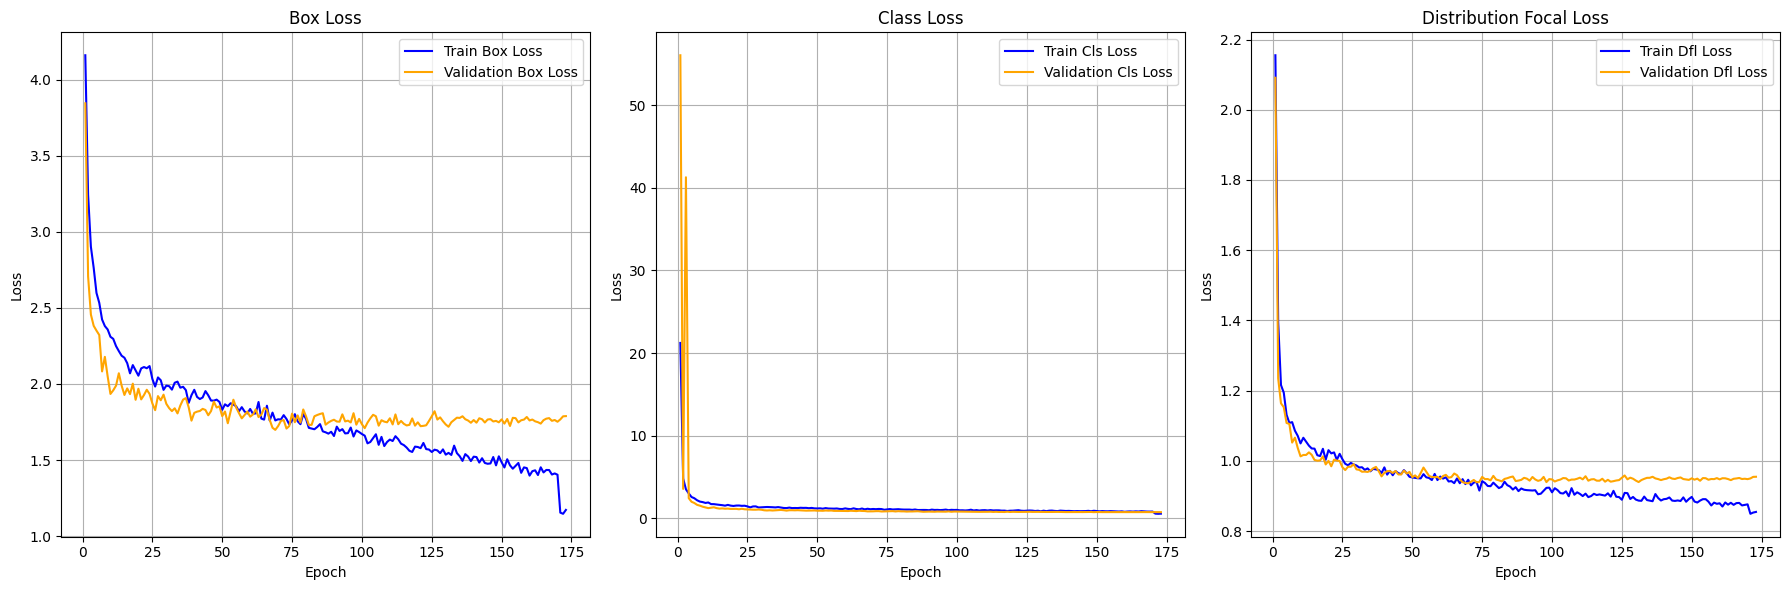

In [36]:
epochs = results_df['epoch']
train_box_loss = results_df['train/box_loss']
val_box_loss = results_df['val/box_loss']
train_cls_loss = results_df['train/cls_loss']
val_cls_loss = results_df['val/cls_loss']
train_dfl_loss = results_df['train/dfl_loss']
val_dfl_loss = results_df['val/dfl_loss']

# Create a figure with three subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot box loss
axs[0].plot(epochs, train_box_loss, label='Train Box Loss', color='blue')
axs[0].plot(epochs, val_box_loss, label='Validation Box Loss', color='orange')
axs[0].set_title('Box Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot cls loss
axs[1].plot(epochs, train_cls_loss, label='Train Cls Loss', color='blue')
axs[1].plot(epochs, val_cls_loss, label='Validation Cls Loss', color='orange')
axs[1].set_title('Class Loss')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

# Plot dfl loss
axs[2].plot(epochs, train_dfl_loss, label='Train Dfl Loss', color='blue')
axs[2].plot(epochs, val_dfl_loss, label='Validation Dfl Loss', color='orange')
axs[2].set_title('Distribution Focal Loss')
axs[2].set_xlabel('Epoch')
axs[2].set_ylabel('Loss')
axs[2].legend()
axs[2].grid(True)

plt.tight_layout()
plt.show()

# 8. Test and visualize predictions

In [48]:
best_model_path = os.path.join(dest_results_dir, 'weights/best.pt')
model = YOLO(best_model_path)

test_data_dir = os.path.join(output_dir, 'images/val')
metrics = model(source=test_data_dir, imgsz=640, conf=0.25, save=True, save_txt=True, save_conf=True)


image 1/34 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/images/val/01_mouse_bite_11.jpg: 640x640 (no detections), 16.2ms
image 2/34 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/images/val/01_spur_02.jpg: 640x640 1 spur, 16.2ms
image 3/34 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/images/val/04_missing_hole_04.jpg: 640x640 3 missing_holes, 16.2ms
image 4/34 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/images/val/04_missing_hole_06.jpg: 640x640 3 missing_holes, 16.2ms
image 5/34 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/images/val/04_mouse_bite_05.jpg: 640x640 3 mouse_bites, 16.2ms
image 6/34 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/images/val/04_open_circuit_11.jpg: 640x640 3 open_circuits, 16.2ms
image 7/34 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/output/images/val/04_open_circuit_15.jpg: 640x640 3 o

In [ ]:
# Prediction outputs are handled from the next cell.


In [58]:
def yolo_to_original_annot(image_name, yolo_labels, annot_df, classes):
    original_annot = []
    original_size = annot_df.loc[annot_df['filename'] == image_name, ['width', 'height']].iloc[0]
    original_width, original_height = original_size['width'], original_size['height']

    for yolo_label in yolo_labels:
        # Support labels with or without confidence scores.
        if len(yolo_label) == 6:
            class_index, x_center, y_center, bbox_width, bbox_height, confidence = yolo_label
        elif len(yolo_label) == 5:
            class_index, x_center, y_center, bbox_width, bbox_height = yolo_label
            confidence = None
        else:
            raise ValueError(f'Unexpected YOLO label format: {yolo_label}')

        # Scale bounding box coordinates and dimensions to original size
        original_x_center = x_center * original_width
        original_y_center = y_center * original_height
        original_bbox_width = bbox_width * original_width
        original_bbox_height = bbox_height * original_height

        # Calculate original bounding box coordinates
        original_x_min = original_x_center - original_bbox_width / 2
        original_y_min = original_y_center - original_bbox_height / 2
        original_x_max = original_x_center + original_bbox_width / 2
        original_y_max = original_y_center + original_bbox_height / 2

        # Append original annotation to list
        row = {
            'filename': image_name,
            'width': int(original_width),
            'height': int(original_height),
            'class': classes[int(class_index)],
            'xmin': int(original_x_min),
            'ymin': int(original_y_min),
            'xmax': int(original_x_max),
            'ymax': int(original_y_max),
        }
        if confidence is not None:
            row['confidence'] = confidence
        original_annot.append(row)

    return pd.DataFrame(original_annot)

In [59]:
image_path = "/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/images/Spurious_copper/12_spurious_copper_10.jpg"
model = YOLO(best_model_path)
pred = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True
)
save_dir = str(pred[0].save_dir)
file_path = os.path.join(save_dir, "labels", Path(image_path).stem + ".txt")


image 1/1 /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/PCB_DATASET/images/Spurious_copper/12_spurious_copper_10.jpg: 640x640 5 spurious_coppers, 16.2ms
Speed: 3.4ms preprocess, 16.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict7
1 label saved to /content/runs/detect/predict7/labels


In [60]:
def read_yolo_labels_from_file(file_path):
    labels = []
    with open(file_path, 'r') as file:
        for line in file:
            values = line.strip().split()
            values = [float(value) for value in values]
            labels.append(values)
    return labels

yolo_labels = read_yolo_labels_from_file(file_path)
yolo_labels

[[5.0, 0.733718, 0.586717, 0.0196663, 0.0360476, 0.812787],
 [5.0, 0.563049, 0.38115, 0.0258345, 0.0236765, 0.79784],
 [5.0, 0.445908, 0.740798, 0.041652, 0.0176973, 0.775228],
 [5.0, 0.141554, 0.654698, 0.0343751, 0.0190414, 0.761693],
 [5.0, 0.714555, 0.150084, 0.0190315, 0.0375659, 0.732029]]

In [61]:
pred_annot_df = yolo_to_original_annot('12_spurious_copper_10.jpg', yolo_labels, annot_df, classes)
pred_annot_df.head()

,filename,width,height,class,xmin,ymin,xmax,ymax,confidence
0,12_spurious_copper_10.jpg,2529,2530,spurious_copper,1830,1438,1880,1529,0.812787
1,12_spurious_copper_10.jpg,2529,2530,spurious_copper,1391,934,1456,994,0.797840
2,12_spurious_copper_10.jpg,2529,2530,spurious_copper,1075,1851,1180,1896,0.775228
3,12_spurious_copper_10.jpg,2529,2530,spurious_copper,314,1632,401,1680,0.761693
4,12_spurious_copper_10.jpg,2529,2530,spurious_copper,1783,332,1831,427,0.732029


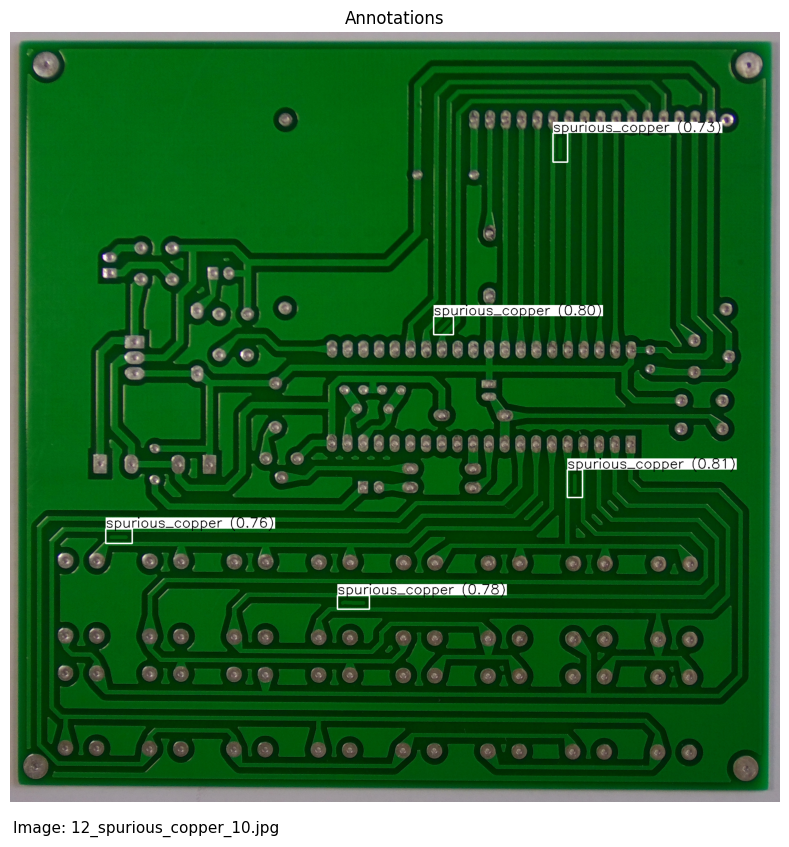

In [62]:
visualize_annotations('12_spurious_copper_10.jpg', images_dir, pred_annot_df, is_subfolder=True);

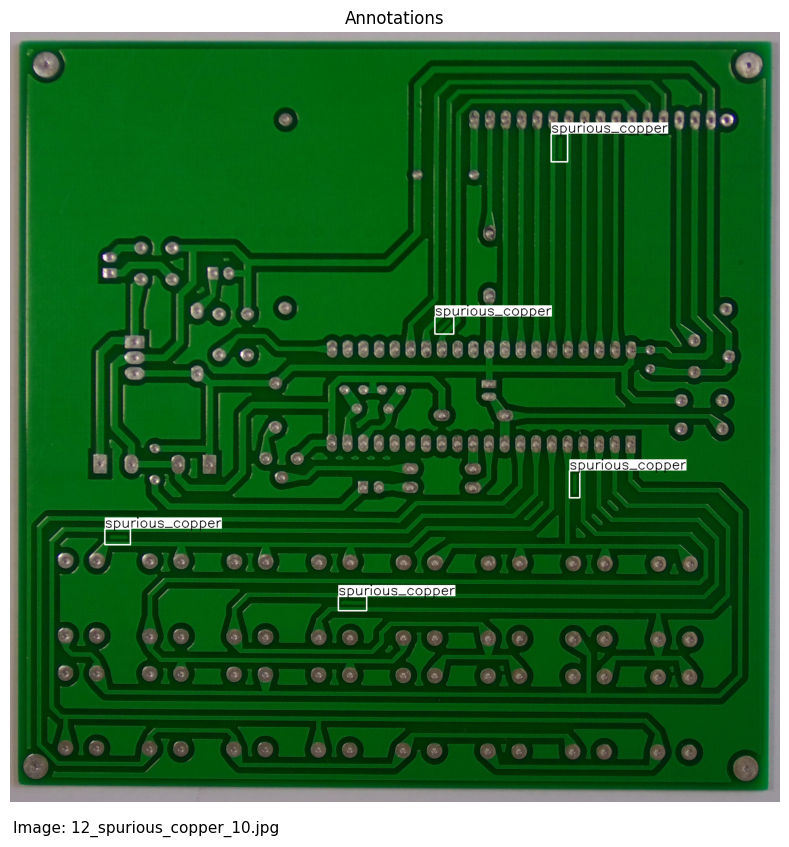

In [63]:
visualize_annotations('12_spurious_copper_10.jpg', images_dir, annot_df, is_subfolder=True);

In [ ]:
model.export()

Ultralytics YOLOv8.2.9 🚀 Python-3.10.12 torch-2.2.1+cu121 CPU (Intel Xeon 2.20GHz)



PyTorch: starting from '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/results/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (21.5 MB)



TorchScript: starting export with torch 2.2.1+cu121...

TorchScript: export success ✅ 2.0s, saved as '/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/results/weights/best.torchscript' (42.9 MB)



Export complete (3.5s)

Results saved to /content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/results/weights

Predict:         yolo predict task=detect model=/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/results/weights/best.torchscript imgsz=640  

Validate:        yolo val task=detect model=/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/results/weights/best.torchscript imgsz=640 data=/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/data.yaml  

Visualize:       https://netron.app


'/content/drive/MyDrive/hripcb_dataset/HRIPCB_UPDATE/results/weights/best.torchscript'